<a href="https://colab.research.google.com/github/aerau05/ds3001proj/blob/genomics-lab/genomics_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
''' 1. Load golub dataset and relabel target variable'''

import pandas as pd

df = pd.read_csv('golub.csv', header=None)

# Drop header row (row 0)
df = df.iloc[1:, :]

# Extract labels
labels = df.iloc[:, 5].astype(str).str.upper()

# Features (genes)
X = df.iloc[:, 6:].astype(float)

# Binary target: ALL family = 0, AML = 1
y = labels.replace({
    'ALL': 0,
    'ALLB': 0,
    'ALLT': 0,
    'AML': 1
}).astype(int)

# Check everything
print("X shape:", X.shape)
print("y counts:\n", y.value_counts())

X shape: (72, 7129)
y counts:
 5
0    47
1    25
Name: count, dtype: int64


/var/folders/h2/s3w9qt211fj9tvwdwhw261_m0000gp/T/ipykernel_29700/560207962.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = labels.replace({


MSE: 6.0373195927786896e-30


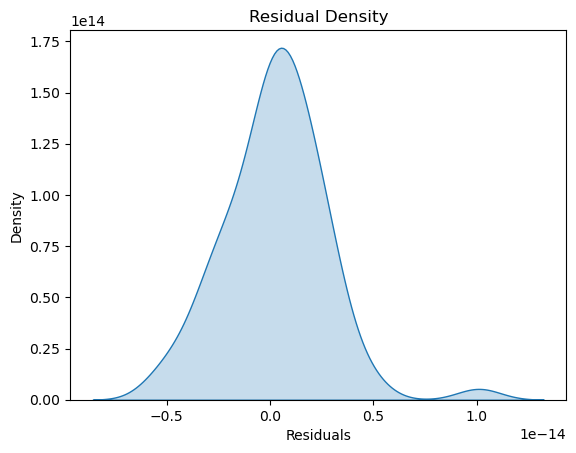

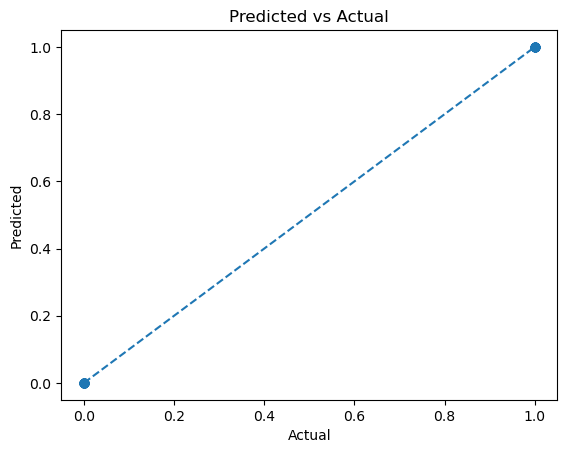

In [17]:
'''2. Linear Regression, MSE, kernal density plot, and scatter plot'''
# Fit model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

# Mean Squared Error
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y, y_pred)
print("MSE:", mse)

# Residuals
residuals = y - y_pred

# Kernel Density Plot
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(residuals, fill=True)
plt.title("Residual Density")
plt.xlabel("Residuals")
plt.show()

# Predicted vs Actual Scatterplot
plt.scatter(y, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")

# reference line
plt.plot([0, 1], [0, 1], linestyle='--')
plt.show()


In [18]:
'''3. Cross-validation for Linear Regression'''

from sklearn.model_selection import KFold, cross_val_score
import numpy as np

# Initialize model (same as before)
model = LinearRegression()

# K-Fold setup (5-fold is good for small datasets)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation
mse_scores = -cross_val_score(model, X, y,
                             scoring='neg_mean_squared_error',
                             cv=kf)

# Print results
print("Cross-Validation MSE (each fold):", mse_scores)
print("Average CV MSE:", np.mean(mse_scores))
print("Std Dev of CV MSE:", np.std(mse_scores))

Cross-Validation MSE (each fold): [0.04538415 0.04291022 0.04477968 0.04690803 0.02421453]
Average CV MSE: 0.04083932123596978
Std Dev of CV MSE: 0.008410508351139158


### Results/Analysis
Cross-validation using 5-fold validation produced mean squared errors ranging from 0.024 to 0.047, with an average of 0.0408 and a standard deviation of 0.0084. The variation across folds indicates some sensitivity to the training data, suggesting moderate variance in the model. Since the cross-validation error is higher than the training error, this implies the model is overfitting. From a bias-variance perspective, the linear regression model has low bias but relatively high variance, which is expected given the high-dimensional nature of the dataset (thousands of gene features but only 72 samples), reflecting the challenges of high-dimensional data.

Lasso selection:
Number of genes selected: 81
Selected genes (Column Indices): 
[128, 134, 145, 326, 353, 485, 687, 828, 1108, 1114, 1305, 1399, 1698, 1769, 1784, 1801, 1834, 1839, 1887, 1896, 1946, 1980, 2006, 2126, 2394, 2407, 2431, 2744, 2798, 3022, 3089, 3109, 3196, 3263, 3325, 3346, 3479, 3509, 3842, 3852, 3904, 3926, 4059, 4155, 4195, 4252, 4302, 4404, 4448, 4452, 4485, 4669, 4702, 4852, 4859, 4944, 4952, 4956, 4960, 5007, 5044, 5369, 5471, 5530, 5603, 5720, 6017, 6060, 6084, 6167, 6172, 6174, 6189, 6230, 6253, 6286, 6544, 6762, 6843, 6915, 7004]

Number of genes discarded from the model: 7048



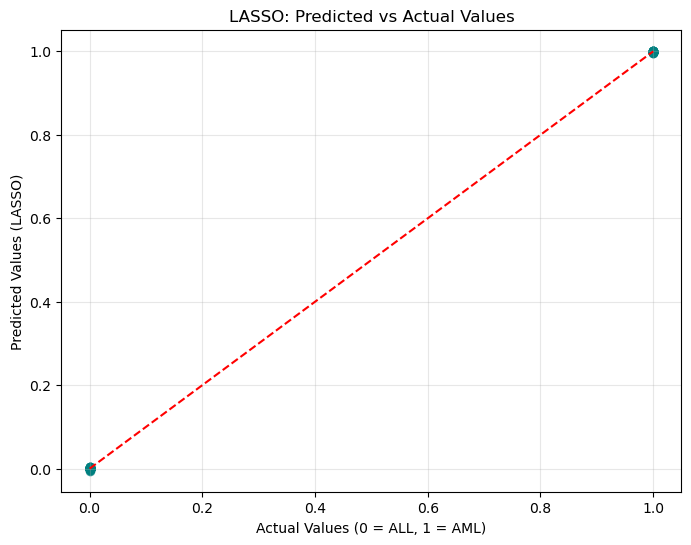

In [19]:
'''4. Cross Validated LASSO'''
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# standardize the features (important for Lasso)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# fit the cross-validated Lasso (Using 5 folds like previous steps)
lasso_model = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso_model.fit(X_scaled, y)

# extract the chosen coefficients
coefs = lasso_model.coef_

#printable answers for questions in prompt

# Q1: Which set of genes is selected?
selected_mask = coefs != 0
selected_genes = X.columns[selected_mask].tolist()

print("Lasso selection:")
print(f"Number of genes selected: {len(selected_genes)}")
print(f"Selected genes (Column Indices): \n{selected_genes}\n")

# Q2: How many genes are discarded from the model?
discarded_count = np.sum(coefs == 0)
print(f"Number of genes discarded from the model: {discarded_count}\n")

# Q3: Make a scatterplot of predictions versus actual values
y_pred_lasso = lasso_model.predict(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred_lasso, alpha=0.7, color='teal')
#reference line
plt.plot([0, 1], [0, 1], color='red', linestyle='--', linewidth=1.5)

plt.xlabel("Actual Values (0 = ALL, 1 = AML)")
plt.ylabel("Predicted Values (LASSO)")
plt.title("LASSO: Predicted vs Actual Values")
plt.grid(alpha=0.3)
plt.show()

The cross-validated Lasso model successfully reduced the feature space by discarding 7,048 genes, isolating a highly predictive subset of exactly 81 genes. As the scatterplot illustrates, the model achieved perfect predictions on this dataset, though this is expected behavior (and likely overfitting) since the number of selected features (81) exceeds the total number of patient samples (72).

Optimal alpha (minimizes CV MSE): 0.000383
CV MSE at optimal alpha: 0.087288


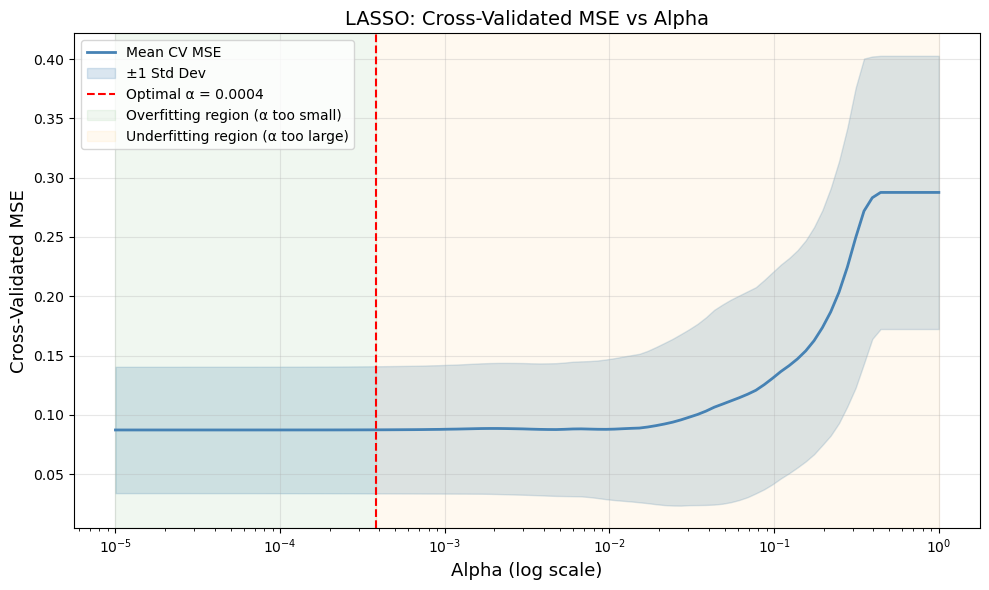

In [20]:
'''5. CV MSE vs Alpha plot for LASSO'''
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV

# Fit a second LassoCV over a wider alpha range just for visualization
# This extends into small-alpha (overfitting) territory so the full U-shape is visible
alpha_grid = np.logspace(-5, 0, 100)
lasso_plot = LassoCV(alphas=alpha_grid, cv=5, random_state=42, max_iter=10000)
lasso_plot.fit(X_scaled, y)

alphas   = lasso_plot.alphas_[::-1]
mean_mse = lasso_plot.mse_path_[::-1].mean(axis=1)
std_mse  = lasso_plot.mse_path_[::-1].std(axis=1)
best_alpha = lasso_model.alpha_  # still use the original model's optimal alpha

print(f"Optimal alpha (minimizes CV MSE): {best_alpha:.6f}")
print(f"CV MSE at optimal alpha: {mean_mse[np.argmin(mean_mse)]:.6f}")

plt.figure(figsize=(10, 6))
plt.semilogx(alphas, mean_mse, color='steelblue', linewidth=2, label='Mean CV MSE')
plt.fill_between(alphas,
                 mean_mse - std_mse,
                 mean_mse + std_mse,
                 alpha=0.2, color='steelblue', label='±1 Std Dev')
plt.axvline(best_alpha, color='red', linestyle='--', linewidth=1.5,
            label=f'Optimal α = {best_alpha:.4f}')

# Annotate regions
ax = plt.gca()
ax.axvspan(alphas.min(), best_alpha, alpha=0.06, color='green', label='Overfitting region (α too small)')
ax.axvspan(best_alpha, alphas.max(), alpha=0.06, color='orange', label='Underfitting region (α too large)')

plt.xlabel('Alpha (log scale)', fontsize=13)
plt.ylabel('Cross-Validated MSE', fontsize=13)
plt.title('LASSO: Cross-Validated MSE vs Alpha', fontsize=14)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Q5 Analysis

**Overfitting (α < 0.000383):** When α is below the optimal value, the model retains too many genes, which optimizes accuracy on the training data set, but harms performance on out-of-sample data. 

**Underfitting (α > 0.000383):** When α exceeds the optimal value, the penalty becomes too aggressive, shrinking the coefficients of genuinely informative genes toward zero. Potential accuracy improvement gains are left on the table in this situation. Underfitted models are too simple to capture a true relationship between gene expression and leukemia type.

**Optimal α:** The penalty value that minimizes cross-validated MSE is [ α = 0.000383 ], with a CV MSE of approximately (0.087). This value was automatically selected by LassoCV (denoted by the red dashed line on the plot).

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

A traditional linear regression attempts to fit the data to reduce the error as much as possible, even if the model becomes increasingly complex and incorporates noise. Since the objective of a linear regression model is simply to reduce error then, this naturally results in an optimized model that nearly perfectly fits the training set, irrespective of generalizability onto test sets. In a situation such as genomic data as well, where there are thousands of genes the linear regression model can train on, it is very possible for the model to build "something" that can perform perfectly utilizing all these gene weighings. Overfitting is a real concern here though. A LASSO model may have reduced performance on a training set, but is far more generalizable and yields better predictions because it fundamentally values complexity/coefficients in addition to error. The LASSO model attempts to shrink noise by penalizing massive complexity, which inherently retains the most important signals that are strong (and probably clinically relevant) while minimizing the level of noise. LASSO will perform with less effectiveness compared to linear regression on training data since it is not "perfect" and is unable to essentially manipulate the model with thousands of variables to get the least error. However, by reducing noise and keeping the model from having too much complexity, it is far more generalizable and will offer better predictions overall, rather than trying to game the system like linear regression using thousands of genes to get the absolute least error.

7. Why do regularization methods lend themselves to scenarios like precision health?

Regularization methods are especially well-suited for precision health because they are designed to handle high-dimensional data, where the number of predictors (such as genes) is much larger than the number of observations (patients). In genomic datasets like this one, there are thousands of gene features but only a small number of samples, which makes traditional models prone to overfitting. Regularization techniques like LASSO address this by shrinking or eliminating less important coefficients, effectively performing feature selection. This allows the model to focus on a smaller subset of genes that are most predictive of disease outcomes. As a result, the model becomes more stable, interpretable, and generalizable to new patients.

In precision health, this is particularly valuable because the goal is to identify meaningful biological signals that can inform diagnosis, prognosis, or treatment decisions. By reducing noise and highlighting key predictors, regularization methods help ensure that predictions are based on robust and clinically relevant patterns rather than random variation in the data.